In [1]:
# =============================================================================
# 性别大战（Battle of Sexes）完整实验代码
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# 设置更有趣的图表风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])

# =============================================================================
# 1. 博弈环境类（性别大战专用）
# =============================================================================
class MatrixGame:
    def __init__(self, payoff_matrix_row, payoff_matrix_col=None):
        self.row_payoff = np.array(payoff_matrix_row)
        if payoff_matrix_col is None:
            self.col_payoff = -self.row_payoff
        else:
            self.col_payoff = np.array(payoff_matrix_col)
        self.num_row_actions = self.row_payoff.shape[0]
        self.num_col_actions = self.row_payoff.shape[1]
    
    def play(self, row_action, col_action):
        return (self.row_payoff[row_action, col_action],
                self.col_payoff[row_action, col_action])

# 定义性别大战收益矩阵
# 行玩家（He）：0=Football, 1=Opera
# 列玩家（She）：0=Football, 1=Opera
BOS_PAYOFF_ROW = [
    [4, 0],   # He: Football
    [0, 2]    # He: Opera
]
BOS_PAYOFF_COL = [
    [2, 0],   # She: Football
    [0, 4]    # She: Opera
]
bos_game = MatrixGame(BOS_PAYOFF_ROW, BOS_PAYOFF_COL)
action_labels = ['Football ⚽', 'Opera 🎭']

print("✅ 性别大战博弈场景定义完成！")

# =============================================================================
# 2. 算法类（复用之前的代码）
# =============================================================================
class MWU:
    def __init__(self, num_actions, learning_rate, min_prob=1e-6, window_size=None, max_loss=5.0):
        self.num_actions = num_actions
        self.learning_rate = learning_rate
        self.min_prob = min_prob
        self.window_size = window_size
        self.max_loss = max_loss
        
        self.log_weights = np.zeros(num_actions)
        self.recent_losses = []
    
    def get_action(self):
        max_log_weight = np.max(self.log_weights)
        weights = np.exp(self.log_weights - max_log_weight)
        probs = weights / np.sum(weights)
        probs = (1 - self.num_actions * self.min_prob) * probs + self.min_prob
        probs = probs / np.sum(probs)
        return np.random.choice(self.num_actions, p=probs)
    
    def update(self, payoffs):
        losses = self.max_loss - payoffs
        self.recent_losses.append(losses)
        
        if self.window_size is not None and len(self.recent_losses) > self.window_size:
            self.recent_losses.pop(0)
        
        if self.window_size is not None:
            self.log_weights = np.zeros(self.num_actions)
            for l in self.recent_losses:
                self.log_weights -= self.learning_rate * l
        else:
            self.log_weights -= self.learning_rate * losses
    
    def reset(self):
        self.log_weights = np.zeros(self.num_actions)
        self.recent_losses = []

def create_gto_mwu(num_actions, T, max_loss=5.0):
    optimal_epsilon = np.sqrt(2 * np.log(num_actions) / T) / max_loss
    return MWU(num_actions, learning_rate=optimal_epsilon, min_prob=1e-6, window_size=None, max_loss=max_loss)

def create_exploitative_mwu(num_actions, epsilon=0.5, window_size=100, max_loss=5.0):
    epsilon = min(epsilon, 5.0)
    return MWU(num_actions, learning_rate=epsilon, min_prob=1e-6, window_size=window_size, max_loss=max_loss)

# =============================================================================
# 3. 并行模拟框架
# =============================================================================
def run_single_simulation(args):
    game, player1, player2, T = args
    player1.reset()
    player2.reset()
    
    p1_cumulative = np.zeros(T)
    p2_cumulative = np.zeros(T)
    p1_actions = np.zeros(T, dtype=int)
    p2_actions = np.zeros(T, dtype=int)
    
    p1_total = 0
    p2_total = 0
    
    for t in range(T):
        a1 = player1.get_action()
        a2 = player2.get_action()
        
        p1_payoff, p2_payoff = game.play(a1, a2)
        
        p1_total += p1_payoff
        p2_total += p2_payoff
        p1_cumulative[t] = p1_total
        p2_cumulative[t] = p2_total
        p1_actions[t] = a1
        p2_actions[t] = a2
        
        p1_all_payoffs = game.row_payoff[:, a2]
        p2_all_payoffs = game.col_payoff[a1, :]
        
        player1.update(p1_all_payoffs)
        player2.update(p2_all_payoffs)
    
    return p1_cumulative, p2_cumulative, p1_actions, p2_actions

def run_simulation(game, player1, player2, T, num_runs=50, max_workers=64):
    args_list = [(game, player1, player2, T) for _ in range(num_runs)]
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(run_single_simulation, args_list))
    
    p1_cumulative_payoffs = np.array([r[0] for r in results])
    p2_cumulative_payoffs = np.array([r[1] for r in results])
    p1_action_history = np.array([r[2] for r in results])
    p2_action_history = np.array([r[3] for r in results])
    
    return p1_cumulative_payoffs, p2_cumulative_payoffs, p1_action_history, p2_action_history

# =============================================================================
# 4. 有趣的绘图函数
# =============================================================================
def plot_cumulative_payoffs_interesting(p1_payoffs, p2_payoffs, labels, title, save_path=None):
    """更有趣的累计收益图"""
    T = p1_payoffs.shape[1]
    x = np.arange(T)
    
    p1_mean = np.mean(p1_payoffs, axis=0)
    p1_std = np.std(p1_payoffs, axis=0)
    p2_mean = np.mean(p2_payoffs, axis=0)
    p2_std = np.std(p2_payoffs, axis=0)
    
    plt.figure(figsize=(12, 7))
    plt.plot(x, p1_mean, label=labels[0], linewidth=3, color='#FF6B6B', linestyle='-')
    plt.fill_between(x, p1_mean - p1_std, p1_mean + p1_std, alpha=0.15, color='#FF6B6B')
    plt.plot(x, p2_mean, label=labels[1], linewidth=3, color='#4ECDC4', linestyle='--')
    plt.fill_between(x, p2_mean - p2_std, p2_mean + p2_std, alpha=0.15, color='#4ECDC4')
    
    # 添加有趣的标注
    mid_point = T // 2
    plt.annotate(f'{labels[0]}: {p1_mean[-1]:.0f}', 
                xy=(T-1, p1_mean[-1]), xytext=(T-5000, p1_mean[-1]+5000),
                arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=2),
                fontsize=11, fontweight='bold', color='#FF6B6B')
    plt.annotate(f'{labels[1]}: {p2_mean[-1]:.0f}', 
                xy=(T-1, p2_mean[-1]), xytext=(T-5000, p2_mean[-1]-5000),
                arrowprops=dict(arrowstyle='->', color='#4ECDC4', lw=2),
                fontsize=11, fontweight='bold', color='#4ECDC4')
    
    plt.xlabel('Round', fontsize=12)
    plt.ylabel('Cumulative Payoff', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()

def plot_action_frequencies_interesting(p1_freq, p2_freq, title, save_path=None):
    """性别大战专用的动作频率图"""
    T = p1_freq.shape[0]
    x = np.arange(T)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # 行玩家（He）
    ax1.plot(x, p1_freq[:, 0], label=action_labels[0], linewidth=2.5, color='#45B7D1')
    ax1.plot(x, p1_freq[:, 1], label=action_labels[1], linewidth=2.5, color='#96CEB4')
    ax1.set_title('His Action Frequency', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.set_ylim([0, 1])
    
    # 列玩家（She）
    ax2.plot(x, p2_freq[:, 0], label=action_labels[0], linewidth=2.5, color='#FF6B6B')
    ax2.plot(x, p2_freq[:, 1], label=action_labels[1], linewidth=2.5, color='#FFEAA7')
    ax2.set_title('Her Action Frequency', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Round', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.set_ylim([0, 1])
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()

def plot_sensitivity_interesting(param_values, avg_payoffs, std_payoffs, param_name, title, save_path=None):
    """更有趣的敏感性分析图"""
    plt.figure(figsize=(11, 6))
    
    # 使用不同的标记和颜色
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    markers = ['o', 's', 'D', '^', 'v']
    
    plt.errorbar(param_values, avg_payoffs, yerr=std_payoffs, 
                fmt='o-', linewidth=3, markersize=10, capsize=8,
                color='#45B7D1', markerfacecolor='#FF6B6B', markeredgecolor='white', markeredgewidth=2)
    
    plt.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Zero Payoff')
    
    # 标注最优值
    optimal_idx = np.argmax(avg_payoffs)
    plt.annotate(f'Optimal: {param_values[optimal_idx]}', 
                xy=(param_values[optimal_idx], avg_payoffs[optimal_idx]), 
                xytext=(param_values[optimal_idx], avg_payoffs[optimal_idx]+2000),
                arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=2),
                fontsize=11, fontweight='bold', color='#FF6B6B',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
    
    plt.xlabel(param_name, fontsize=12)
    plt.ylabel('Average Payoff', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()

def track_action_frequencies(game, player1, player2, T):
    p1_freq = np.zeros((T, game.num_row_actions))
    p2_freq = np.zeros((T, game.num_col_actions))
    
    p1_counts = np.zeros(game.num_row_actions)
    p2_counts = np.zeros(game.num_col_actions)
    
    player1.reset()
    player2.reset()
    
    for t in range(T):
        a1 = player1.get_action()
        a2 = player2.get_action()
        
        p1_counts[a1] += 1
        p2_counts[a2] += 1
        
        p1_freq[t, :] = p1_counts / (t+1)
        p2_freq[t, :] = p2_counts / (t+1)
        
        p1_all_payoffs = game.row_payoff[:, a2]
        p2_all_payoffs = game.col_payoff[a1, :]
        
        player1.update(p1_all_payoffs)
        player2.update(p2_all_payoffs)
    
    return p1_freq, p2_freq

print("✅ 所有辅助函数定义完成！")

✅ 性别大战博弈场景定义完成！
✅ 所有辅助函数定义完成！



========== 实验1：GTO vs GTO ==========


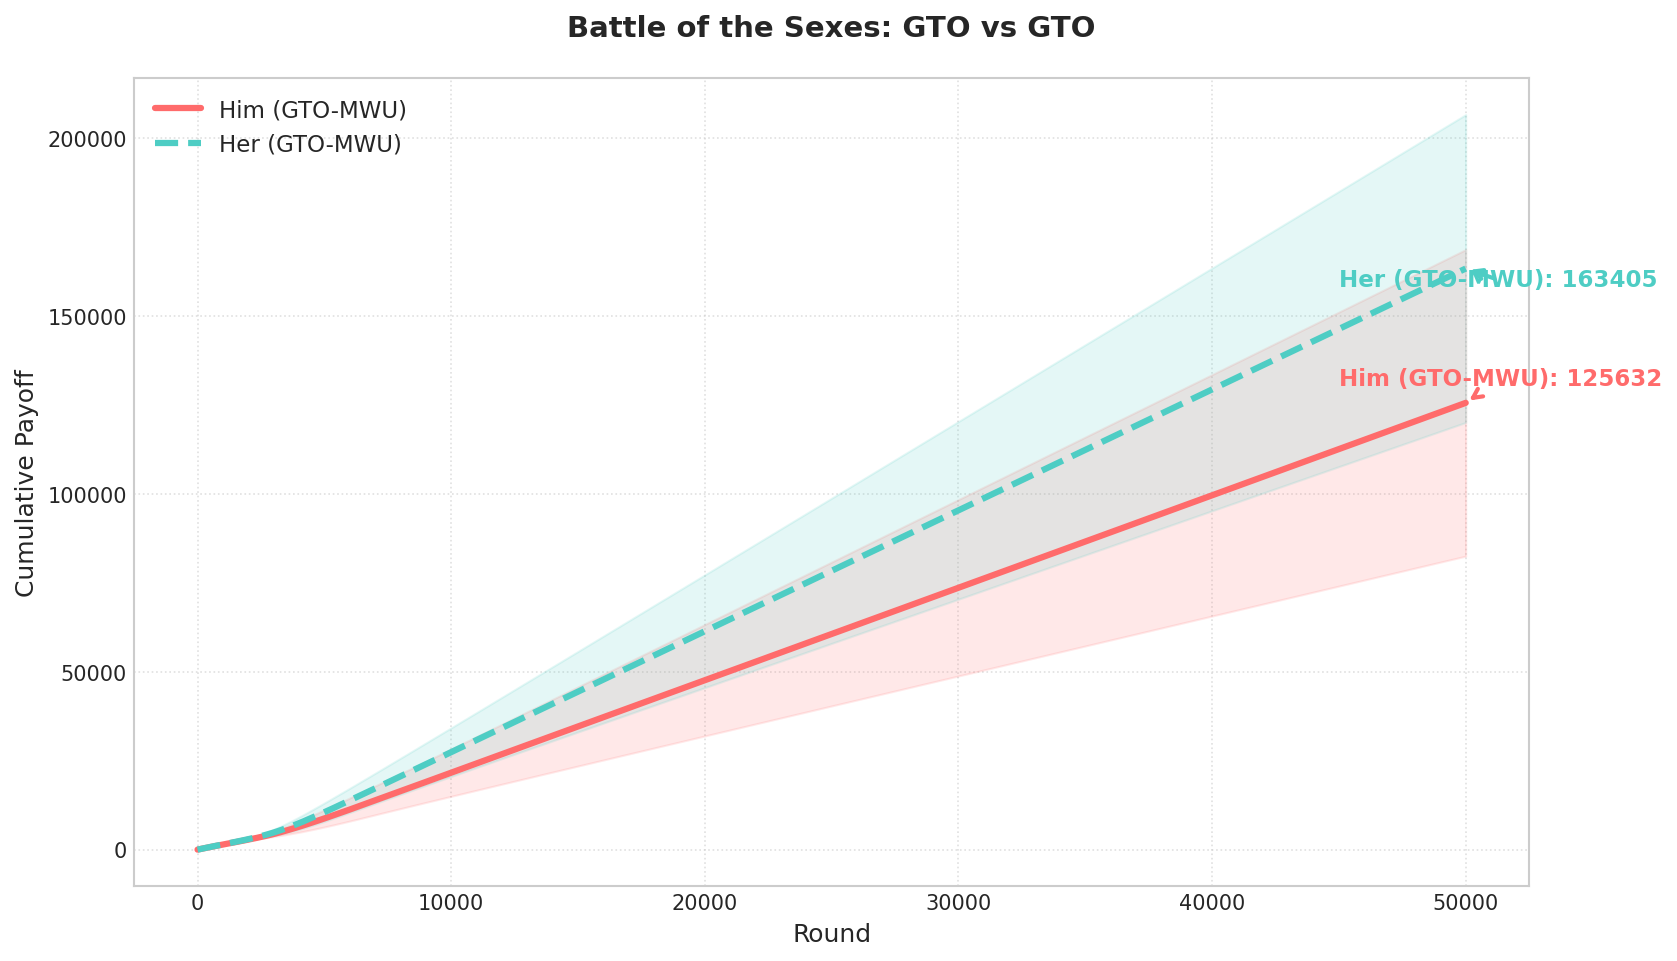

Tracking action frequencies...


/tmp/ipykernel_353744/3819072874.py:212: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_353744/3819072874.py:212: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_353744/3819072874.py:215: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight', dpi=200)
/tmp/ipykernel_353744/3819072874.py:215: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight', dpi=200)
/home/swachan/.conda/envs/ieda4000i/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/swachan/.conda/envs/ieda4000i/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing 

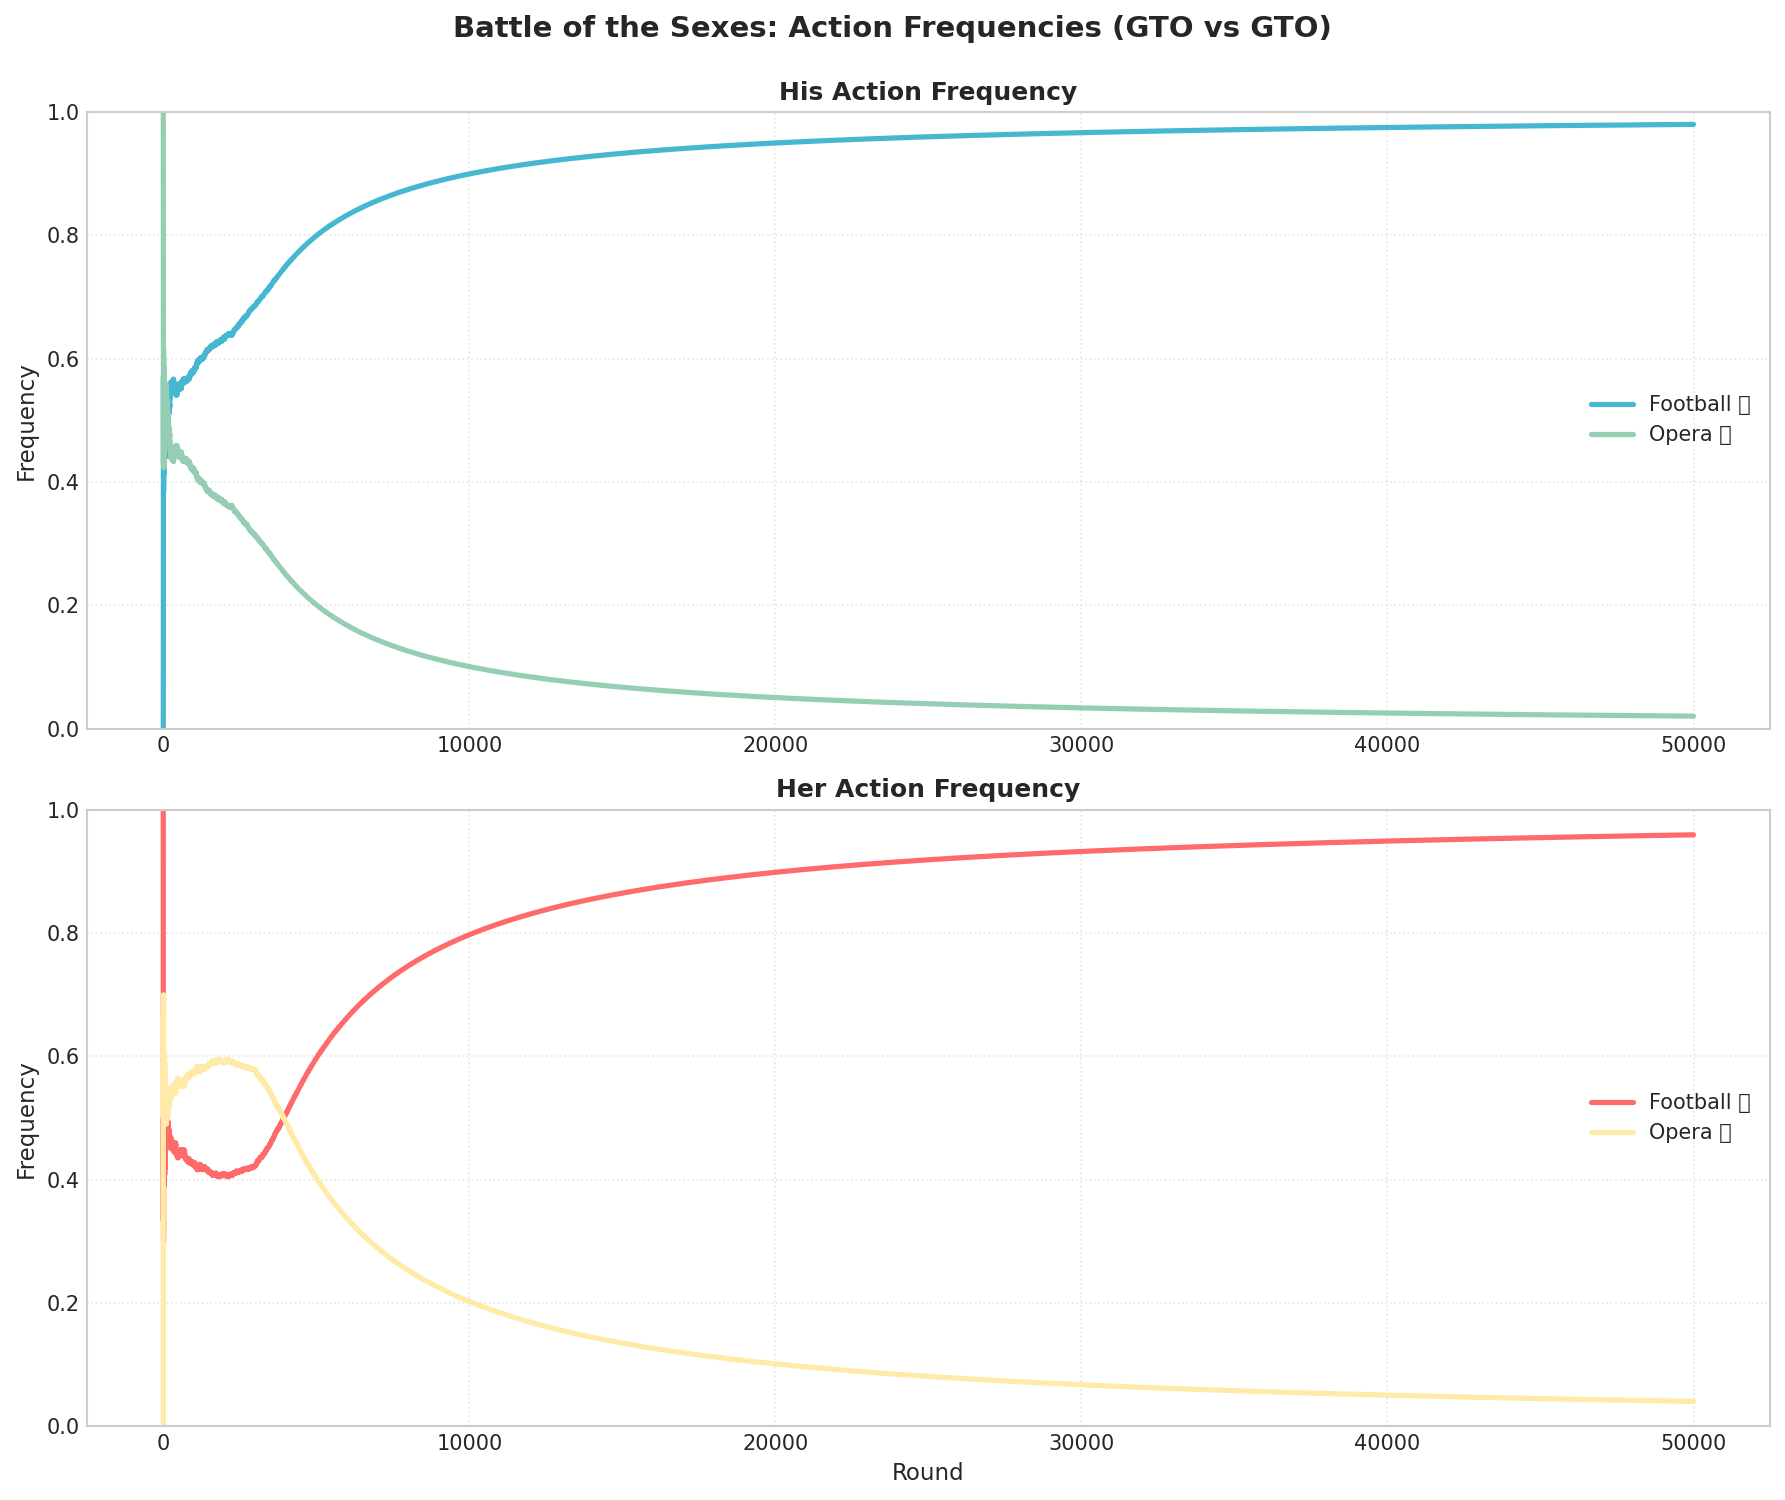


========== 实验2：Exploitative vs Exploitative ==========


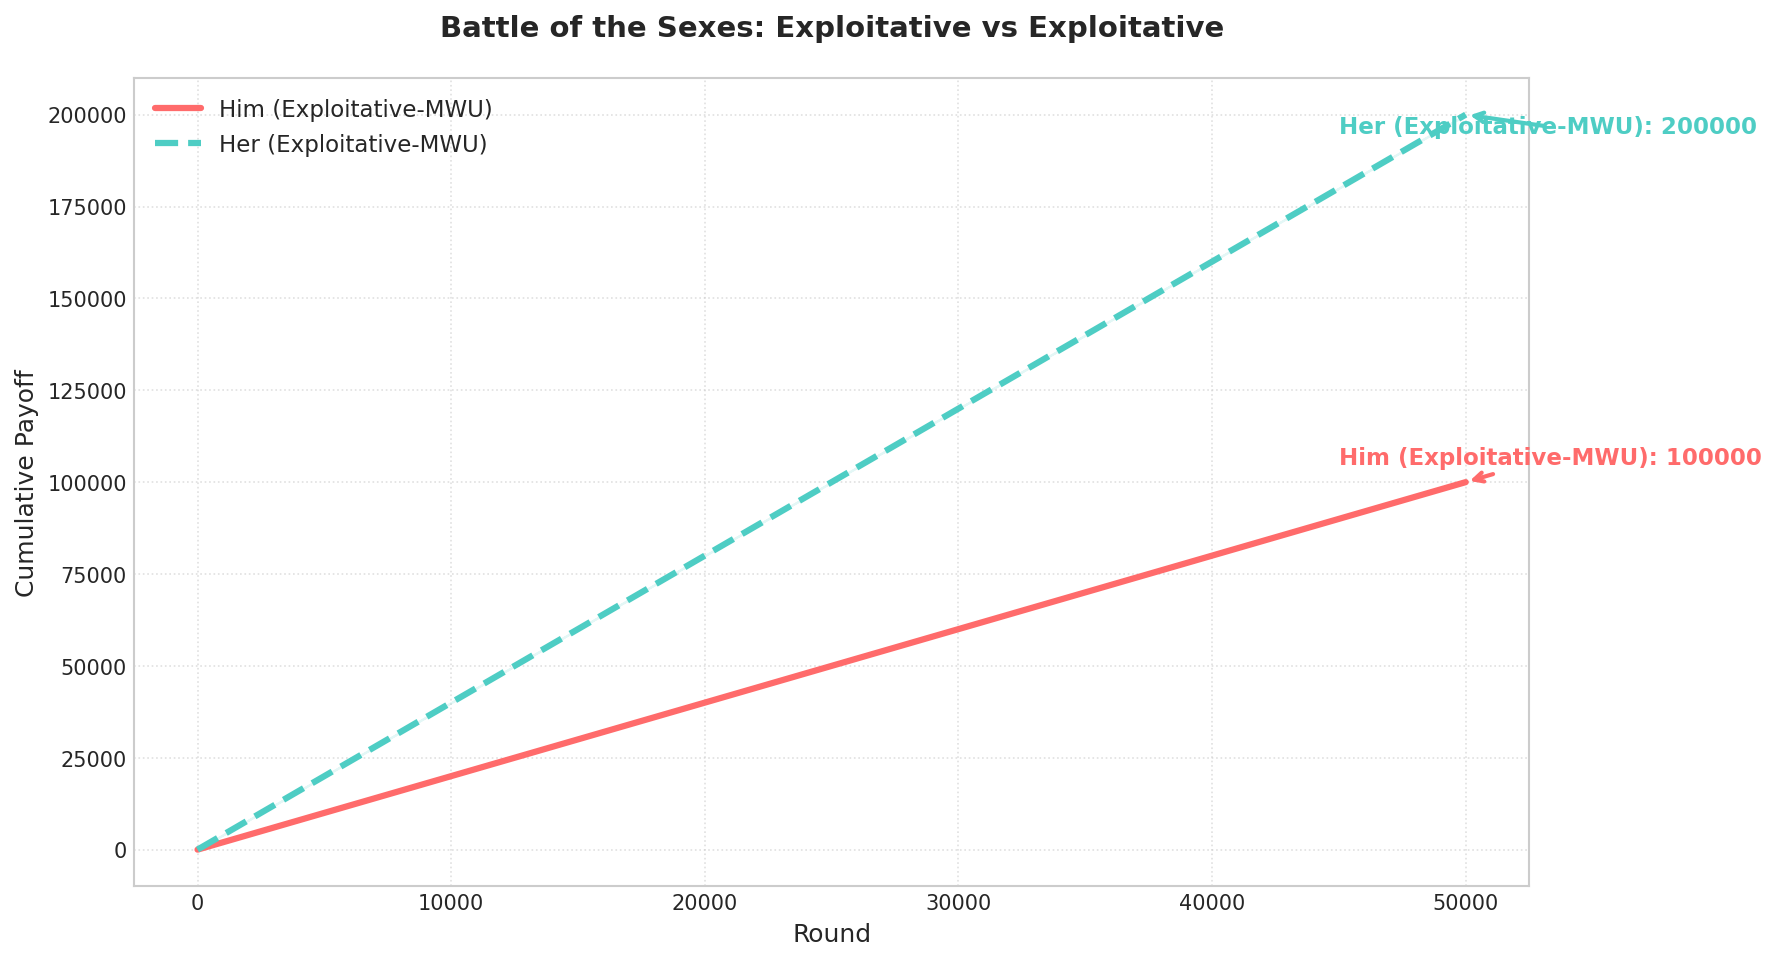

Tracking action frequencies...


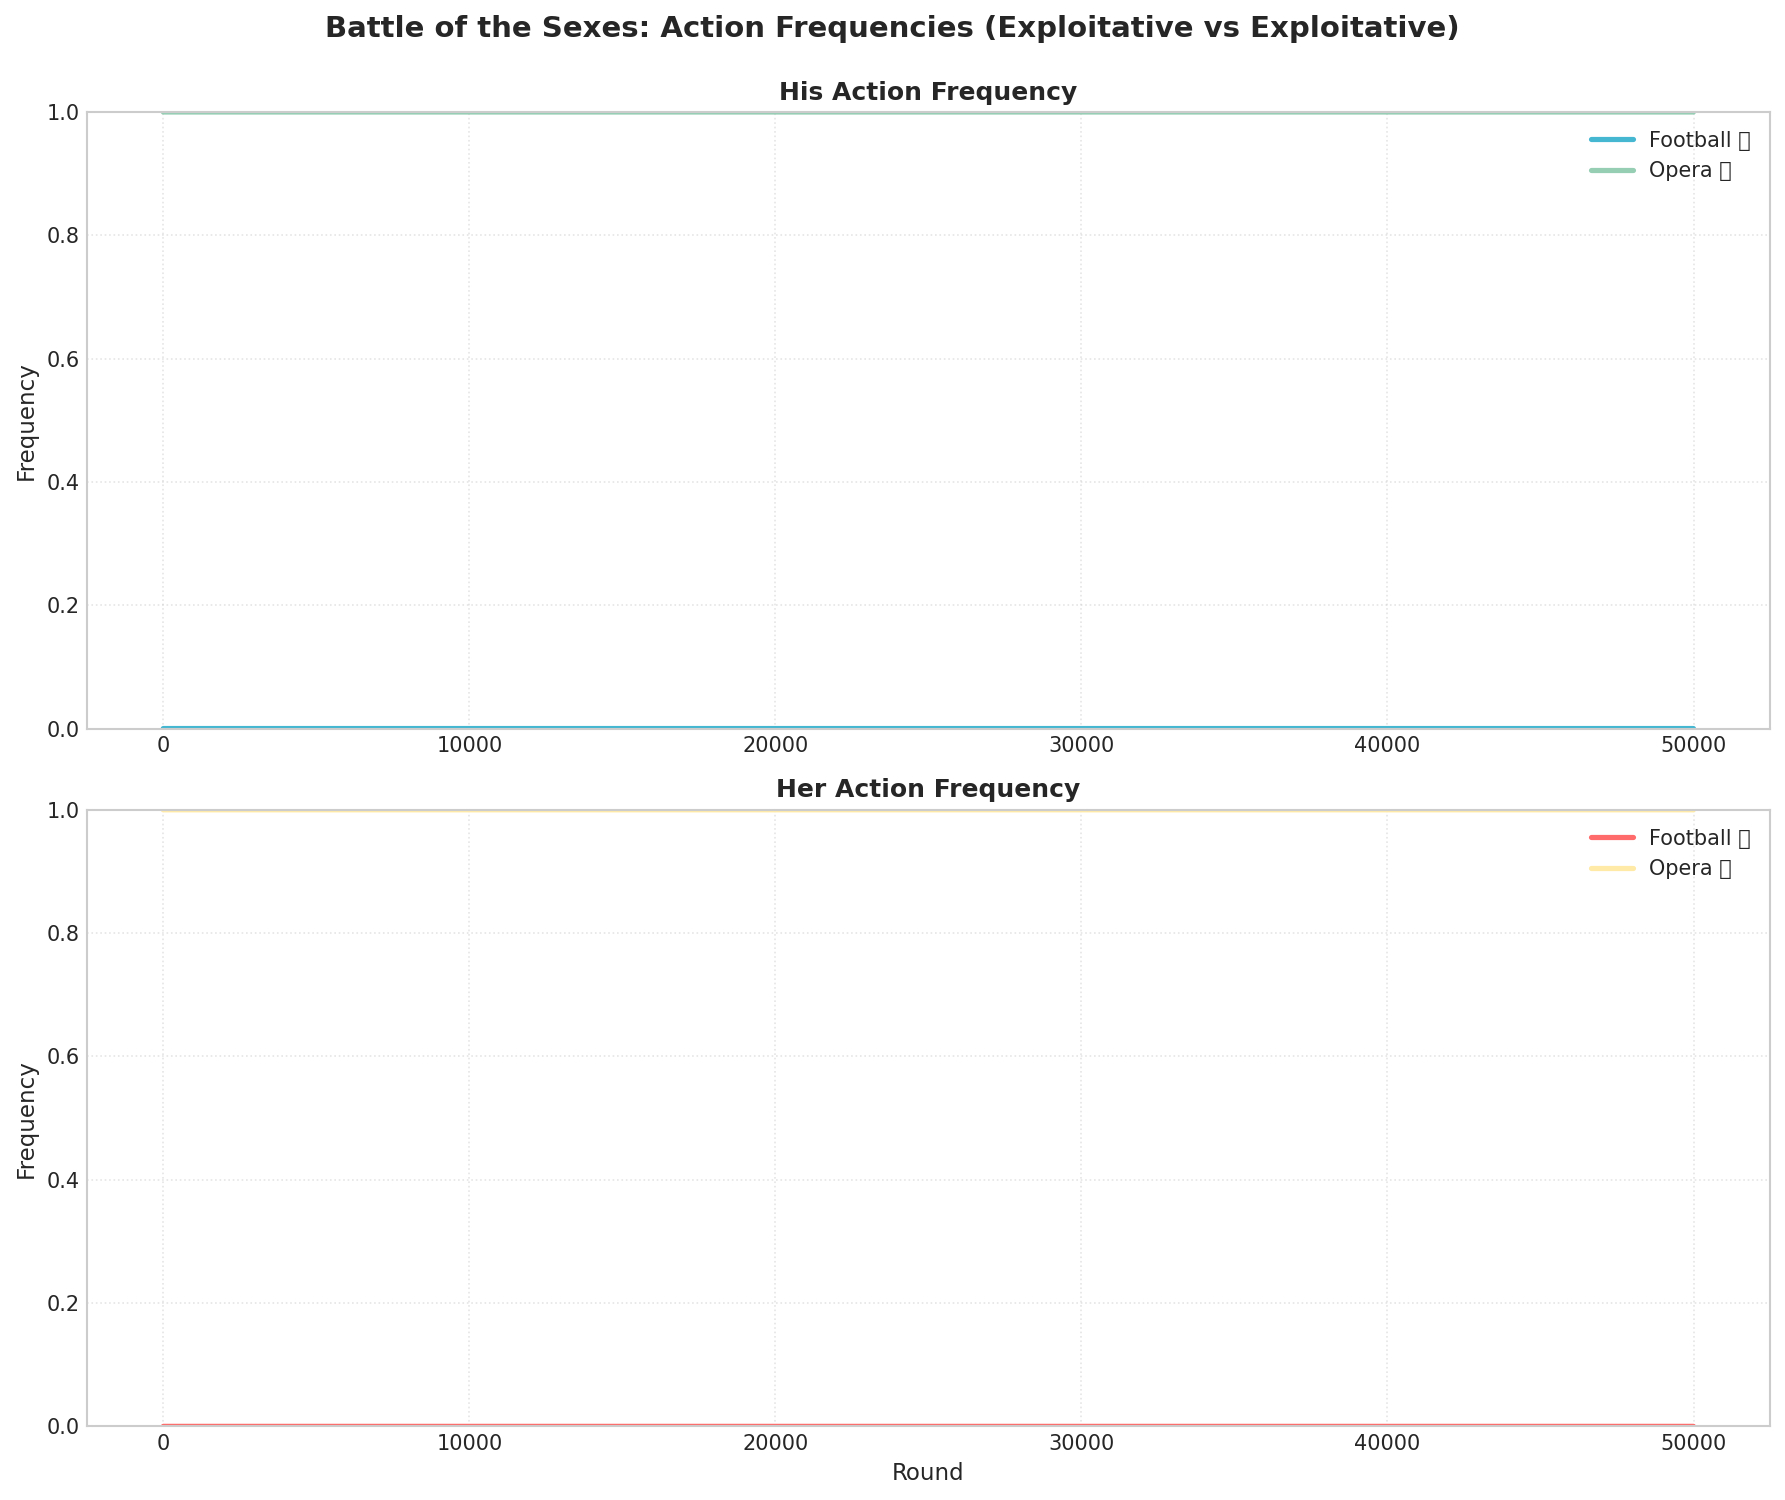


========== 实验3：GTO vs Exploitative ==========


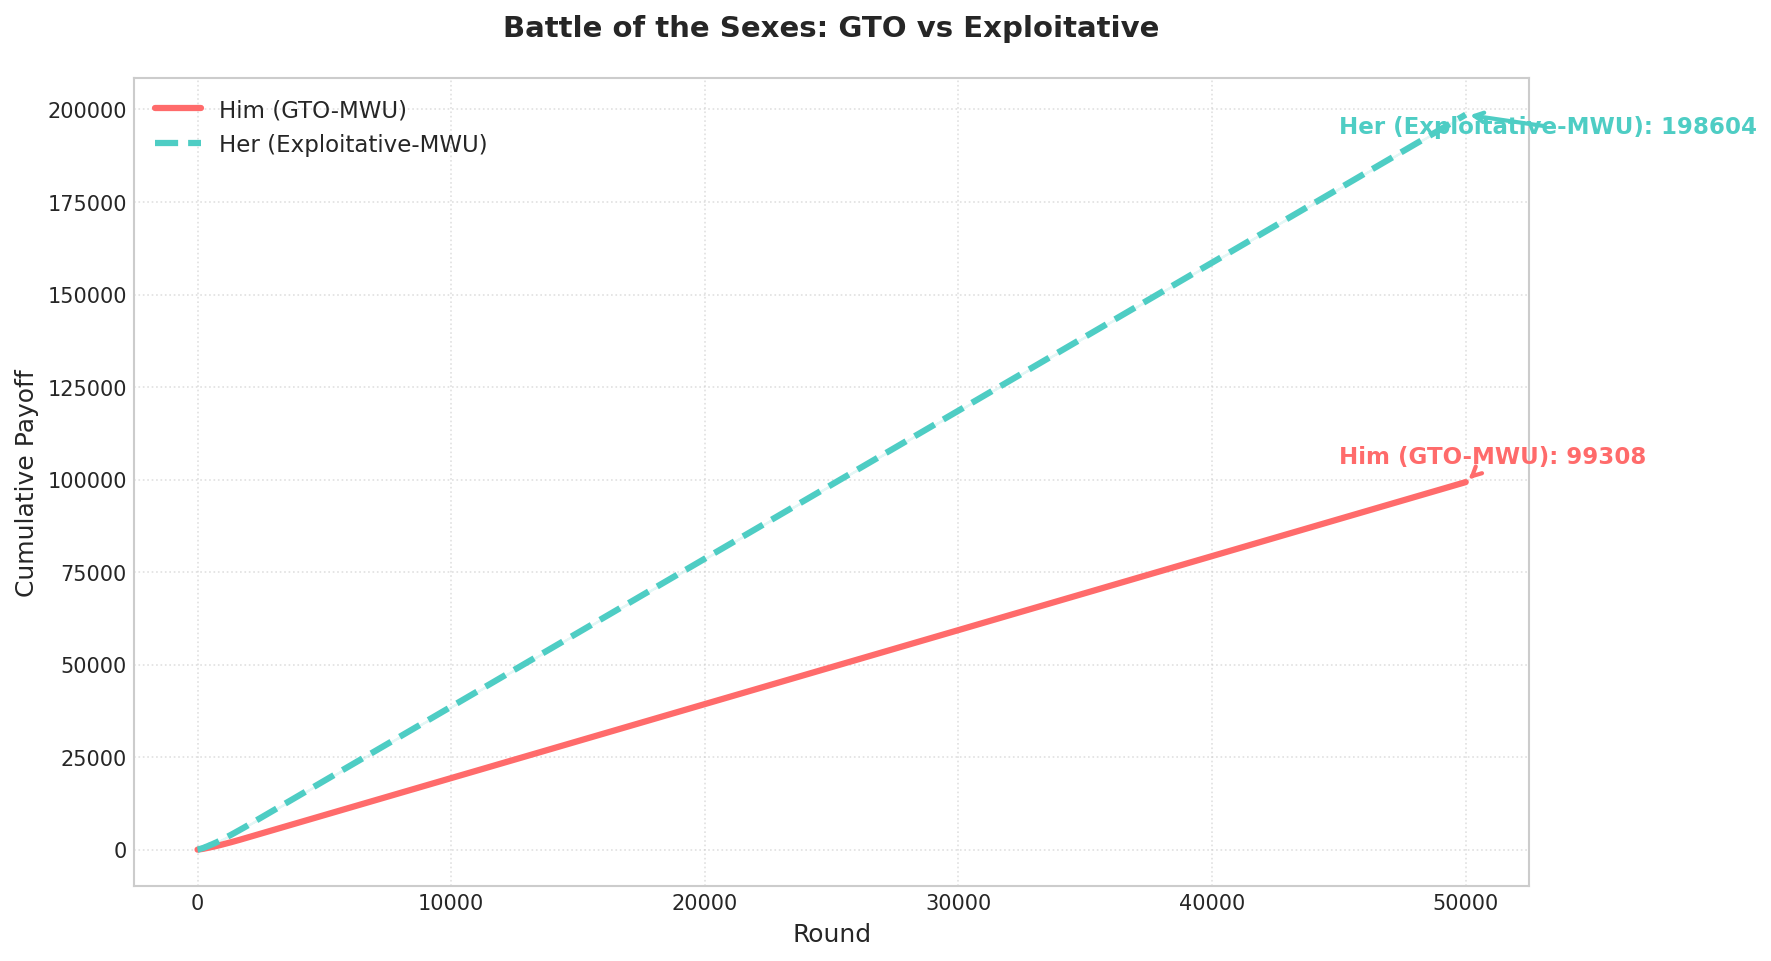


✅ 性别大战基础实验完成！


In [2]:
# =============================================================================
# 性别大战基础实验
# =============================================================================
T = 50000
num_runs = 30
game = bos_game

print("\n========== 实验1：GTO vs GTO ==========")
gto1 = create_gto_mwu(game.num_row_actions, T, max_loss=5.0)
gto2 = create_gto_mwu(game.num_col_actions, T, max_loss=5.0)
gto_vs_gto_p1, gto_vs_gto_p2, _, _ = run_simulation(game, gto1, gto2, T, num_runs)

plot_cumulative_payoffs_interesting(
    gto_vs_gto_p1, gto_vs_gto_p2,
    ['Him (GTO-MWU)', 'Her (GTO-MWU)'],
    'Battle of the Sexes: GTO vs GTO',
    'bos_gto_vs_gto.png'
)

print("Tracking action frequencies...")
gto_p1_freq, gto_p2_freq = track_action_frequencies(game, gto1, gto2, T)
plot_action_frequencies_interesting(
    gto_p1_freq, gto_p2_freq,
    'Battle of the Sexes: Action Frequencies (GTO vs GTO)',
    'bos_gto_action_freq.png'
)

print("\n========== 实验2：Exploitative vs Exploitative ==========")
exploit1 = create_exploitative_mwu(game.num_row_actions, epsilon=0.3, window_size=100, max_loss=5.0)
exploit2 = create_exploitative_mwu(game.num_col_actions, epsilon=0.3, window_size=100, max_loss=5.0)
exploit_vs_exploit_p1, exploit_vs_exploit_p2, _, _ = run_simulation(game, exploit1, exploit2, T, num_runs)

plot_cumulative_payoffs_interesting(
    exploit_vs_exploit_p1, exploit_vs_exploit_p2,
    ['Him (Exploitative-MWU)', 'Her (Exploitative-MWU)'],
    'Battle of the Sexes: Exploitative vs Exploitative',
    'bos_exploit_vs_exploit.png'
)

print("Tracking action frequencies...")
exploit_p1_freq, exploit_p2_freq = track_action_frequencies(game, exploit1, exploit2, T)
plot_action_frequencies_interesting(
    exploit_p1_freq, exploit_p2_freq,
    'Battle of the Sexes: Action Frequencies (Exploitative vs Exploitative)',
    'bos_exploit_action_freq.png'
)

print("\n========== 实验3：GTO vs Exploitative ==========")
gto_player = create_gto_mwu(game.num_row_actions, T, max_loss=5.0)
exploit_player = create_exploitative_mwu(game.num_col_actions, epsilon=0.3, window_size=100, max_loss=5.0)
gto_vs_exploit_p1, gto_vs_exploit_p2, _, _ = run_simulation(game, gto_player, exploit_player, T, num_runs)

plot_cumulative_payoffs_interesting(
    gto_vs_exploit_p1, gto_vs_exploit_p2,
    ['Him (GTO-MWU)', 'Her (Exploitative-MWU)'],
    'Battle of the Sexes: GTO vs Exploitative',
    'bos_gto_vs_exploit.png'
)

print("\n✅ 性别大战基础实验完成！")


========== 高级实验1：学习率敏感性分析（简化版） ==========
Running Learning Rate ε = 0.01...
Average payoff: 190682.00 ± 0.00
Running Learning Rate ε = 0.05...
Average payoff: 198484.00 ± 0.00
Running Learning Rate ε = 0.1...
Average payoff: 198512.00 ± 0.00
Running Learning Rate ε = 0.5...
Average payoff: 198606.00 ± 0.00
Running Learning Rate ε = 1.0...
Average payoff: 198610.00 ± 0.00


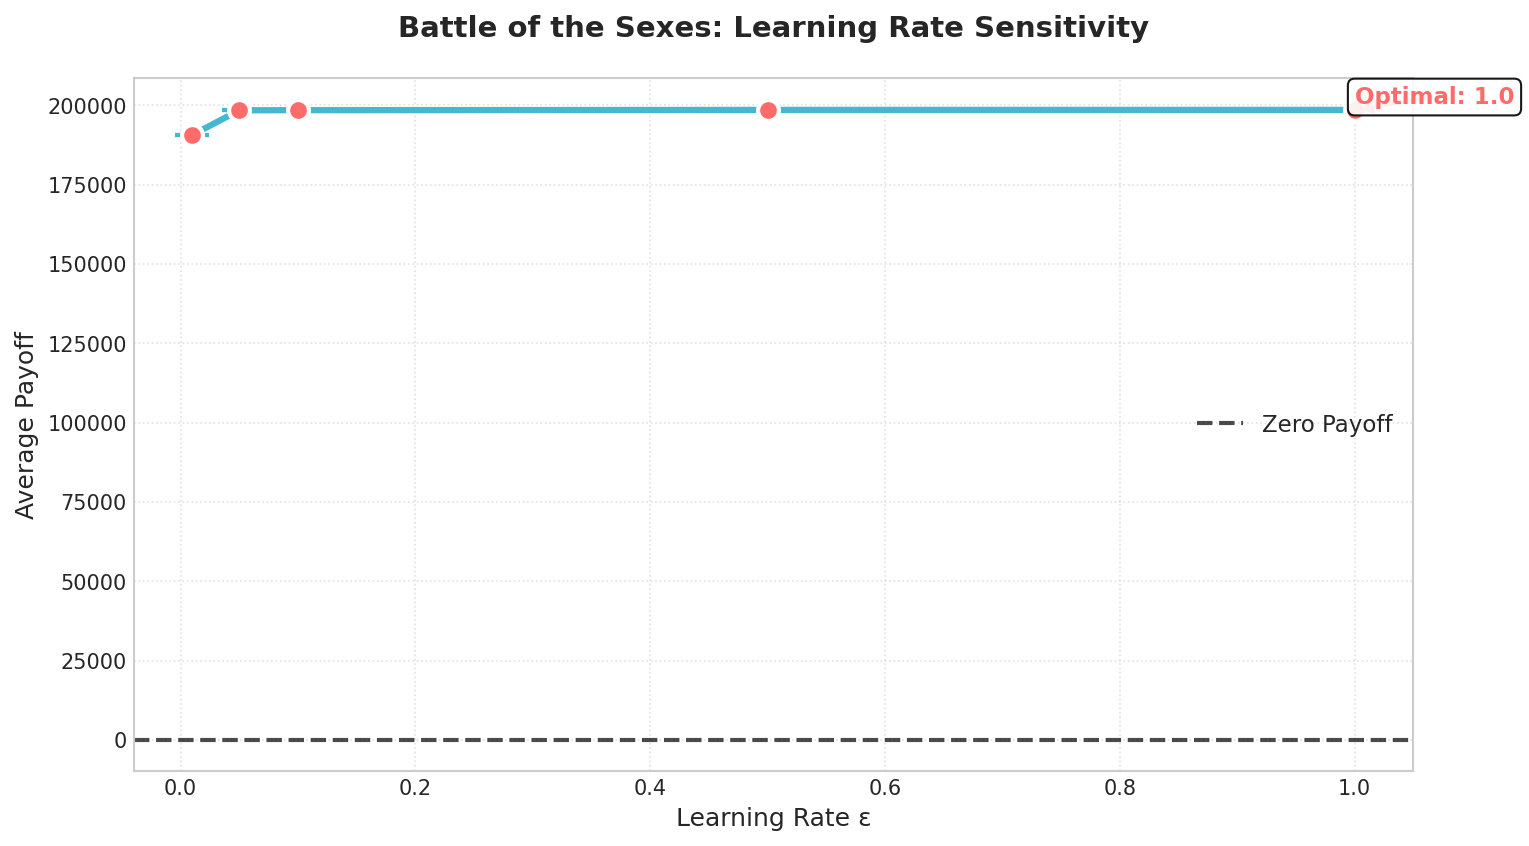


最优学习率: 1.0

========== 高级实验2：窗口大小敏感性分析（简化版） ==========
Running Window Size = 10...
Average payoff: 198106.00 ± 0.00
Running Window Size = 50...
Average payoff: 198610.00 ± 0.00
Running Window Size = 100...
Average payoff: 198610.00 ± 0.00
Running Window Size = 200...
Average payoff: 198610.00 ± 0.00
Running Window Size = 500...
Average payoff: 198610.00 ± 0.00


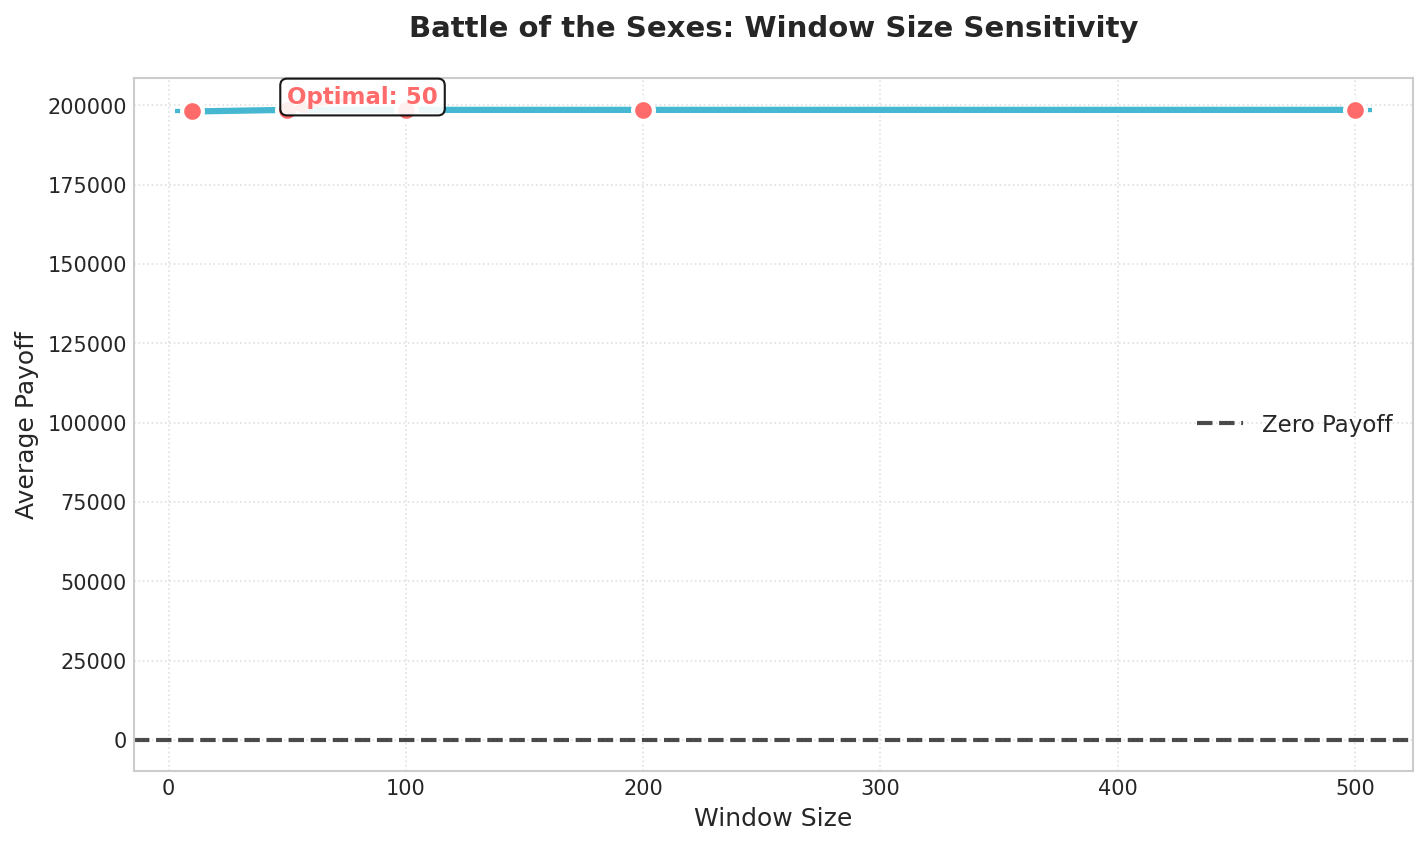


最优窗口大小: 50

✅ 性别大战高级实验完成！


In [3]:
# =============================================================================
# 性别大战高级实验（简化参数）
# =============================================================================
T = 50000
num_runs = 20
game = bos_game

def run_learning_rate_sensitivity_bos(game, epsilons, T=50000, num_runs=20):
    avg_payoffs = []
    std_payoffs = []
    
    for epsilon in epsilons:
        print(f"Running Learning Rate ε = {epsilon}...")
        gto_player = create_gto_mwu(game.num_row_actions, T, max_loss=5.0)
        exploit_player = create_exploitative_mwu(game.num_col_actions, epsilon=epsilon, window_size=100, max_loss=5.0)
        p1_payoffs, p2_payoffs, _, _ = run_simulation(game, gto_player, exploit_player, T, num_runs)
        avg_p2 = np.mean(p2_payoffs[:, -1])
        std_p2 = np.std(p2_payoffs[:, -1])
        avg_payoffs.append(avg_p2)
        std_payoffs.append(std_p2)
        print(f"Average payoff: {avg_p2:.2f} ± {std_p2:.2f}")
    
    return avg_payoffs, std_payoffs

def run_window_size_sensitivity_bos(game, window_sizes, optimal_epsilon, T=50000, num_runs=20):
    avg_payoffs = []
    std_payoffs = []
    
    for window_size in window_sizes:
        print(f"Running Window Size = {window_size}...")
        gto_player = create_gto_mwu(game.num_row_actions, T, max_loss=5.0)
        exploit_player = create_exploitative_mwu(game.num_col_actions, epsilon=optimal_epsilon, window_size=window_size, max_loss=5.0)
        p1_payoffs, p2_payoffs, _, _ = run_simulation(game, gto_player, exploit_player, T, num_runs)
        avg_p2 = np.mean(p2_payoffs[:, -1])
        std_p2 = np.std(p2_payoffs[:, -1])
        avg_payoffs.append(avg_p2)
        std_payoffs.append(std_p2)
        print(f"Average payoff: {avg_p2:.2f} ± {std_p2:.2f}")
    
    return avg_payoffs, std_payoffs

print("\n========== 高级实验1：学习率敏感性分析（简化版） ==========")
epsilons = [0.01, 0.05, 0.1, 0.5, 1.0]  # 简化参数范围
epsilon_avg, epsilon_std = run_learning_rate_sensitivity_bos(game, epsilons, T, num_runs)

plot_sensitivity_interesting(
    epsilons, epsilon_avg, epsilon_std,
    'Learning Rate ε',
    'Battle of the Sexes: Learning Rate Sensitivity',
    'bos_learning_rate.png'
)

optimal_idx = np.argmax(epsilon_avg)
optimal_epsilon = epsilons[optimal_idx]
print(f"\n最优学习率: {optimal_epsilon}")

print("\n========== 高级实验2：窗口大小敏感性分析（简化版） ==========")
window_sizes = [10, 50, 100, 200, 500]  # 简化参数范围
window_avg, window_std = run_window_size_sensitivity_bos(game, window_sizes, optimal_epsilon, T, num_runs)

plot_sensitivity_interesting(
    window_sizes, window_avg, window_std,
    'Window Size',
    'Battle of the Sexes: Window Size Sensitivity',
    'bos_window_size.png'
)

optimal_window_idx = np.argmax(window_avg)
optimal_window_size = window_sizes[optimal_window_idx]
print(f"\n最优窗口大小: {optimal_window_size}")

print("\n✅ 性别大战高级实验完成！")